# Problema de negocio
Predecir el riesgo financiero de clientes para apoyar decisiones de crédito y reducir pérdidas por incumplimiento.

 # 0. Preparación


Cargue de librerias e importación de dataset

In [ ]:
# 0. Preparación del entorno y carga de datos

# Importar librerías básicas
import numpy as np  # Álgebra lineal y utilidades numéricas
import pandas as pd  # Manejo de dataframes
from sklearn import datasets  # Conjuntos de datos de sklearn
from sklearn.model_selection import train_test_split  # División train/test
from sklearn.preprocessing import StandardScaler  # Estandarización de variables
from sklearn.pipeline import Pipeline  # Para encadenar escalado + modelo
from sklearn.model_selection import StratifiedKFold, KFold  # Validación cruzada k-fold
from sklearn.model_selection import GridSearchCV  # Búsqueda de hiperparámetros

# Métricas de clasificación
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

# Métricas de regresión
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Modelos de clasificación
from sklearn.linear_model import LogisticRegression  # Clasificación lineal probabilística
from sklearn.svm import SVC  # Máquinas de soporte vectorial para clasificación
from sklearn.neighbors import KNeighborsClassifier  # k-NN
from sklearn.tree import DecisionTreeClassifier  # Árbol de decisión

# Modelos de regresión
from sklearn.linear_model import LinearRegression, Lasso, Ridge  # Modelos lineales
from sklearn.svm import SVR  # Support Vector Regression

print("Librerias cargasdas exitosamente")

Librerias cargasdas exitosamente


In [ ]:
# Cargue de dataset

df = pd.read_csv("/content/drive/MyDrive/machien learning/Actividad_final/dataset_credito_unificado.csv")
print("Archivo cargado exitosamente")

Archivo cargado exitosamente


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 01. Exploración inicial (Analisis exploratorio)

In [ ]:
dimensiones = df.shape
print(f"El DataFrame tiene {dimensiones[0]}, filas y {dimensiones[1]}, columnas.")

El DataFrame tiene 36457, filas y 25, columnas.


In [ ]:
# columnas
nombres_columnas = list(df.columns)
print(nombres_columnas)

['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'edad_anios', 'antiguedad_laboral_anios', 'num_meses_hist', 'num_meses_mora', 'meses_sin_deuda', 'hay_cuenta_cerrada', 'max_mora_num', 'porc_meses_mora', 'TARGET', 'ultimo_status', 'mes_ultima_mora', 'status_ultima_mora', 'recencia_ultima_mora']


In [ ]:
# Información del dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        36457 non-null  int64  
 1   CODE_GENDER               36457 non-null  object 
 2   FLAG_OWN_CAR              36457 non-null  object 
 3   FLAG_OWN_REALTY           36457 non-null  object 
 4   CNT_CHILDREN              36457 non-null  int64  
 5   AMT_INCOME_TOTAL          36457 non-null  float64
 6   NAME_INCOME_TYPE          36457 non-null  object 
 7   NAME_EDUCATION_TYPE       36457 non-null  object 
 8   NAME_FAMILY_STATUS        36457 non-null  object 
 9   NAME_HOUSING_TYPE         36457 non-null  object 
 10  OCCUPATION_TYPE           25134 non-null  object 
 11  CNT_FAM_MEMBERS           36457 non-null  float64
 12  edad_anios                36457 non-null  float64
 13  antiguedad_laboral_anios  30322 non-null  float64
 14  num_me

Se evidencia valore faltantes en la variables "OCCUPATION_TYPE", "antiguedad_laboral_anios", "max_mora_num",

In [ ]:
# Cantidad y porcentaje de valores nulos

print("=== Cantidad de valores faltantes ===")
print(df.isna().sum())

print("\n=== Porcentaje de valores faltantes ===")
# (suma / total) * 100 y luego redondear
porcentaje_nulos = (df.isna().sum() / len(df)) * 100
print(porcentaje_nulos.round(2))

=== Cantidad de valores faltantes ===
ID                              0
CODE_GENDER                     0
FLAG_OWN_CAR                    0
FLAG_OWN_REALTY                 0
CNT_CHILDREN                    0
AMT_INCOME_TOTAL                0
NAME_INCOME_TYPE                0
NAME_EDUCATION_TYPE             0
NAME_FAMILY_STATUS              0
NAME_HOUSING_TYPE               0
OCCUPATION_TYPE             11323
CNT_FAM_MEMBERS                 0
edad_anios                      0
antiguedad_laboral_anios     6135
num_meses_hist                  0
num_meses_mora                  0
meses_sin_deuda                 0
hay_cuenta_cerrada              0
max_mora_num                 4455
porc_meses_mora                 0
TARGET                          0
ultimo_status                   0
mes_ultima_mora             32166
status_ultima_mora          32166
recencia_ultima_mora        32166
dtype: int64

=== Porcentaje de valores faltantes ===
ID                           0.00
CODE_GENDER             

Hay variables con datos falatantes: "OCCUPATION_TYPE" tiene 31% esta es una variable categorica habla sobre el tipo de ocupación se imputara con "desconocido" porque es relevante para la predicción, la variable "max_mora_num" se imputara con "0" Si es nulo es porque nunca hubo mora, la variable "antiguedad_laboral_anios" Si es nulo, es probable que la persona no trabaje se imputrara con "0", en las variables "mes_ultima_mora" ,"status_ultima_mora", "recencia_ultima_mora" se hara una acción de interpretación de negocio en crédito estas variables que estan vacías suele significar que el cliente nunca ha tenido una mora. No es que falte el dato, es que el evento no ha ocurrido. Se creara una variable binaria llamada TIENE_HISTORIAL_MORA.Si el valor es nulo = 0. Si tiene valor = 1.

In [ ]:
# Estadisiticas descriptivas

df.describe()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,CNT_FAM_MEMBERS,edad_anios,antiguedad_laboral_anios,num_meses_hist,num_meses_mora,meses_sin_deuda,hay_cuenta_cerrada,max_mora_num,porc_meses_mora,TARGET,mes_ultima_mora,status_ultima_mora,recencia_ultima_mora
count,3.645700e+04,36457.000000,3.645700e+04,36457.000000,36457.000000,30322.000000,36457.000000,36457.000000,36457.000000,36457.000000,32002.000000,36457.000000,36457.000000,4291.000000,4291.000000,4291.000000
mean,5.078227e+06,0.430315,1.866857e+05,2.198453,43.738802,7.242994,21.332392,0.317497,4.003346,0.492361,0.175458,0.015624,0.016897,-18.764624,1.261244,18.764624
std,4.187524e+04,0.742367,1.017892e+05,0.911686,11.499888,6.454230,14.911849,1.531811,8.667466,0.499948,0.555245,0.064393,0.128886,14.947821,0.862606,14.947821
min,5.008804e+06,0.000000,2.700000e+04,1.000000,20.500000,0.046543,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-59.000000,1.000000,0.000000
25%,5.042028e+06,0.000000,1.215000e+05,2.000000,34.100000,2.677618,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-30.000000,1.000000,5.000000
50%,5.074614e+06,0.000000,1.575000e+05,2.000000,42.600000,5.453799,18.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,-16.000000,1.000000,16.000000
75%,5.115396e+06,1.000000,2.250000e+05,3.000000,53.200000,9.596167,31.000000,0.000000,3.000000,1.000000,0.000000,0.000000,0.000000,-5.000000,1.000000,30.000000
max,5.150487e+06,19.000000,1.575000e+06,20.000000,68.900000,43.019849,61.000000,49.000000,61.000000,1.000000,5.000000,1.000000,1.000000,0.000000,5.000000,59.000000


La edad promedio de los solicitantes es de 43.7 años, la edad mínima de la persona solicitante es de 20.5 años y la máxima es de 69 años, la media de antoguedad de años es de 7.2 años

# Limpieza de datos

In [ ]:
# copia del dataset

df_limpio = df.copy()

In [ ]:
# Eliminar posibles espacios en blanco residuales en todas las columnas tipo object
df_limpio = df_limpio.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

In [ ]:
# Normalización de las columnas mayusculas a minsuculas

# Minúsculas en columnas
df_limpio.columns = [col.lower() for col in df_limpio.columns]

# Minúsculas en todos los datos de texto
df_limpio = df_limpio.applymap(lambda s: s.lower() if type(s) == str else s)

/tmp/ipykernel_10487/2007875533.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_limpio = df_limpio.applymap(lambda s: s.lower() if type(s) == str else s)


In [ ]:
df_limpio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        36457 non-null  int64  
 1   code_gender               36457 non-null  object 
 2   flag_own_car              36457 non-null  object 
 3   flag_own_realty           36457 non-null  object 
 4   cnt_children              36457 non-null  int64  
 5   amt_income_total          36457 non-null  float64
 6   name_income_type          36457 non-null  object 
 7   name_education_type       36457 non-null  object 
 8   name_family_status        36457 non-null  object 
 9   name_housing_type         36457 non-null  object 
 10  occupation_type           25134 non-null  object 
 11  cnt_fam_members           36457 non-null  float64
 12  edad_anios                36457 non-null  float64
 13  antiguedad_laboral_anios  30322 non-null  float64
 14  num_me

In [ ]:
# Isnpección y eliminación de duplicados



# Calcular el número de duplicados

num_duplicados = df_limpio.duplicated().sum()
print(f"Duplicados encontrados: {num_duplicados:,}")

# 2. porcentaje
porcentaje_duplicados = (num_duplicados / len(df)) * 100

# 3. Eliminar duplicados

df_clear = df_limpio.drop_duplicates()

print(f"Porcentaje de duplicados: {porcentaje_duplicados:.2f}%")
print(f"{num_duplicados:,} duplicados eliminados")
print(f"Registros después de eliminar duplicados: {len(df_clear):,}")


print(f"Duplicados eliminados: {num_duplicados} ({porcentaje_duplicados:.2f}%)")


Duplicados encontrados: 0
Porcentaje de duplicados: 0.00%
0 duplicados eliminados
Registros después de eliminar duplicados: 36,457
Duplicados eliminados: 0 (0.00%)


No se encontraton valores duplicados

# Tratamiento de nulos

In [ ]:
# 1. Imputación occupation
df_limpio["occupation_type"] = df_limpio["occupation_type"].fillna("desconocido")

# 2. Imputación de max_mora_num
df_limpio["max_mora_num"] = df_limpio["max_mora_num"].fillna(0)

# 3. Imputación de antiguedad_laboral_anios
df_limpio["antiguedad_laboral_anios"] = df_limpio["antiguedad_laboral_anios"].fillna(0)


Se hizo imputación en la variable "occupation_type" con  "desconocido" por estrategia de negocio de crédito porque es relevante para la predicción, la variable "max_mora_num" se imputo con "0" porque si es nulo es porque nunca hubo mora, la variable "antiguedad_laboral_anios" Si es nulo, es probable que la persona no trabaje se imputo con "0"

In [ ]:
# Creación de la variable binaria basada en una de las columnas con 88% de nulos
# Usamos .notna() que devuelve True si tiene valor y False si es nulo
# se convierte a entero (True -> 1, False -> 0)

df_limpio['tiene_historial_mora'] = df_limpio['mes_ultima_mora'].notna().astype(int)

# Verificación que se haya creado correctamente
print("Distribución de la nueva variable:")
print(df_limpio['tiene_historial_mora'].value_counts())

# Eliminación de las columnas originales con exceso de nulos
columnas_a_eliminar = ["mes_ultima_mora", "status_ultima_mora", "recencia_ultima_mora"]
df_limpio = df_limpio.drop(columns=columnas_a_eliminar)

print(f"\nColumnas eliminadas: {columnas_a_eliminar}")

Distribución de la nueva variable:
tiene_historial_mora
0    32166
1     4291
Name: count, dtype: int64

Columnas eliminadas: ['mes_ultima_mora', 'status_ultima_mora', 'recencia_ultima_mora']


In [ ]:
df_limpio.to_csv("riesgo_crediticio_dashboard.csv", index=False)

en las variables "mes_ultima_mora" ,"status_ultima_mora", "recencia_ultima_mora" se hara una acción de interpretación de negocio en crédito estas variables que estan vacías suele significar que el cliente nunca ha tenido una mora, Se creo una variable binaria llamada TIENE_HISTORIAL_MORA.Si el valor es nulo = 0. Si tiene valor = 1.

# 3. Preprocesamiento

# Outliers

In [ ]:
# variables numéricas a analizar
cols_numericas = [
    'amt_income_total', 'cnt_children', 'cnt_fam_members',
    'edad_anios', 'antiguedad_laboral_anios', 'num_meses_hist',
    'num_meses_mora', 'meses_sin_deuda', 'max_mora_num', 'porc_meses_mora'
]

# Lista para guardar los resultados
resultados_outliers = []

for col in cols_numericas:
    serie = pd.to_numeric(df_limpio[col], errors="coerce").dropna()

    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1

    Li = Q1 - 1.5 * IQR
    Ls = Q3 + 1.5 * IQR

    # Conteo y porcentaje
    conteo_va = ((serie < Li) | (serie > Ls)).sum()
    total = serie.shape[0]
    porcentaje = round(100 * conteo_va / total, 2)

    # Guardamos en la lista
    resultados_outliers.append({
        "Variable": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Min_Limit": Li,
        "Max_Limit": Ls,
        "Cant_Atipicos": conteo_va,
        "Porcentaje %": porcentaje
    })

# Convertimos a DataFrame
df_outliers = pd.DataFrame(resultados_outliers)

# resultado
print(df_outliers.to_string(index=False))

# Filtro solo las que tienen outliers
print("\nVariables con presencia de Outliers:")
print(df_outliers[df_outliers['Cant_Atipicos'] > 0][['Variable', 'Cant_Atipicos', 'Porcentaje %']])

                Variable            Q1            Q3         IQR     Min_Limit     Max_Limit  Cant_Atipicos  Porcentaje %
        amt_income_total 121500.000000 225000.000000 103500.0000 -33750.000000 380250.000000           1529          4.19
            cnt_children      0.000000      1.000000      1.0000     -1.500000      2.500000            508          1.39
         cnt_fam_members      2.000000      3.000000      1.0000      0.500000      4.500000            480          1.32
              edad_anios     34.100000     53.200000     19.1000      5.450000     81.850000              0          0.00
antiguedad_laboral_anios      1.117043      8.632444      7.5154    -10.156057     19.905544           1770          4.86
          num_meses_hist      9.000000     31.000000     22.0000    -24.000000     64.000000              0          0.00
          num_meses_mora      0.000000      0.000000      0.0000      0.000000      0.000000           4291         11.77
         meses_sin_deuda

Se detecta outliers en 10 variables, la variable con mas alto porcentaje es "meses_sin_deuda" es de 15.42% se hara tramiento de winsorización

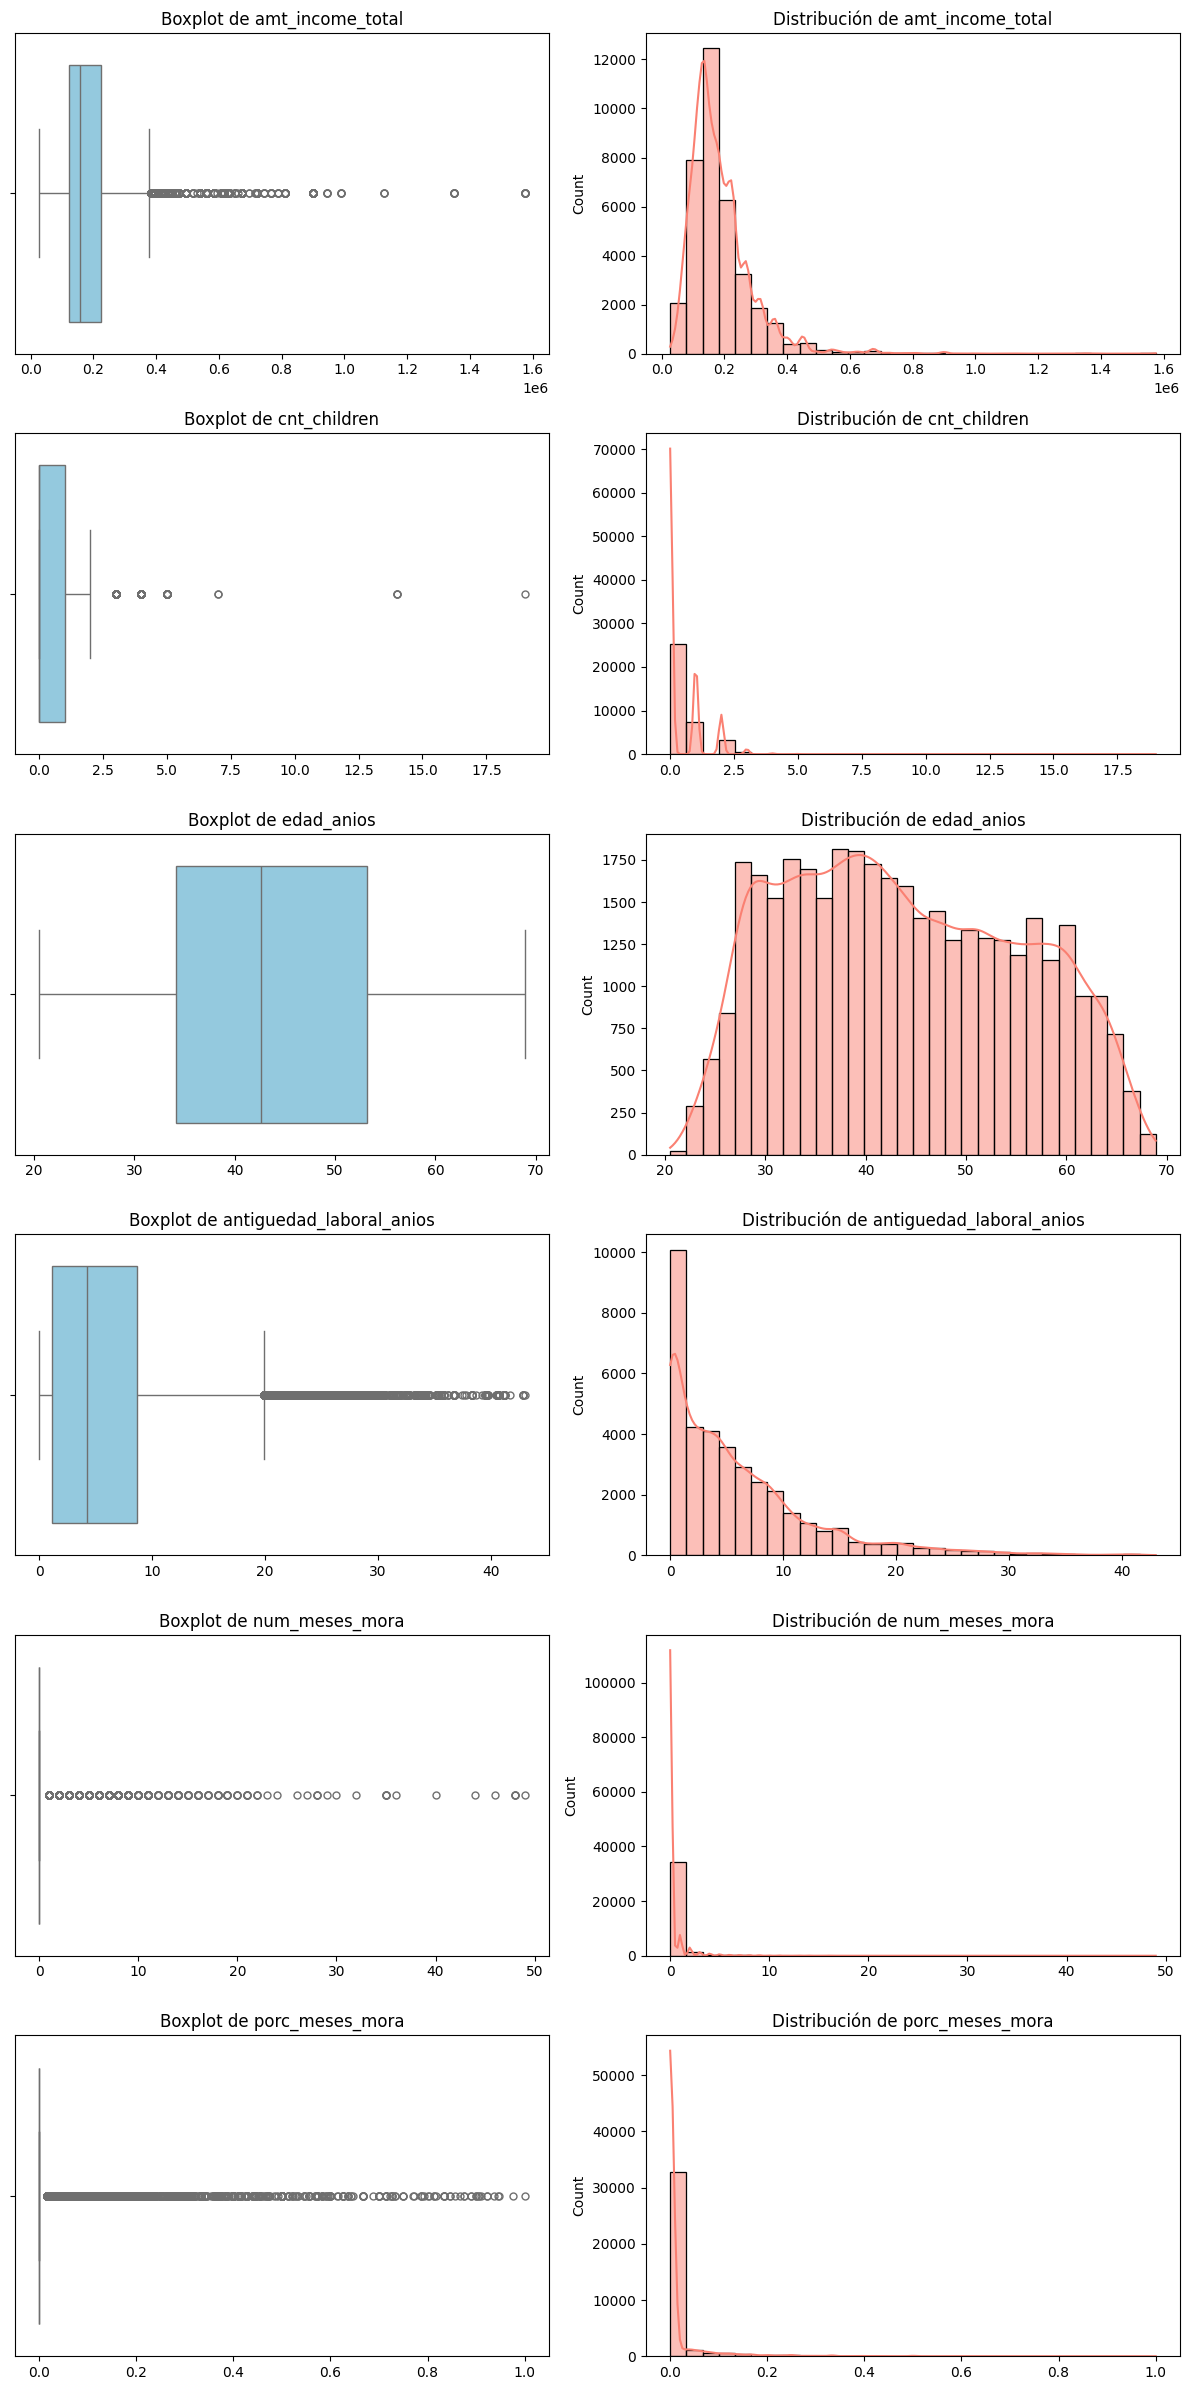

In [ ]:
# Graficos de outliers

import matplotlib.pyplot as plt
import seaborn as sns

# Usamos la misma lista de variables numéricas anterior
cols_numericas = [
    'amt_income_total', 'cnt_children', 'edad_anios',
    'antiguedad_laboral_anios', 'num_meses_mora', 'porc_meses_mora'
]

# Configuramos el tamaño de la figura
n_cols = len(cols_numericas)
fig, axes = plt.subplots(n_cols, 2, figsize=(12, 4 * n_cols))

for i, col in enumerate(cols_numericas):
    # Boxplot (Lado izquierdo)
    sns.boxplot(x=df_limpio[col], ax=axes[i, 0], color='skyblue', fliersize=5)
    axes[i, 0].set_title(f'Boxplot de {col}')
    axes[i, 0].set_xlabel('')

    # Histograma
    sns.histplot(df_limpio[col], kde=True, ax=axes[i, 1], color='salmon', bins=30)
    axes[i, 1].set_title(f'Distribución de {col}')
    axes[i, 1].set_xlabel('')

plt.tight_layout()
plt.show()

# Metodo de winsorización para tratamiento de variables outliers

In [ ]:
# variables aplicar la limpieza
cols_a_limpiar = [
    'amt_income_total', 'cnt_children', 'cnt_fam_members',
    'edad_anios', 'antiguedad_laboral_anios', 'num_meses_mora',
    'porc_meses_mora', 'max_mora_num'
]

# Aseguramos solo df_limpio
cols_presentes = [c for c in cols_a_limpiar if c in df_limpio.columns]

print("=== Iniciando proceso de Winsorización ===")

for col in cols_presentes:
    # Calculamos límites para esta columna específica
    Q1 = df_limpio[col].quantile(0.25)
    Q3 = df_limpio[col].quantile(0.75)
    IQR = Q3 - Q1

    Li = Q1 - 1.5 * IQR
    Ls = Q3 + 1.5 * IQR

    # Aplicamos el clipping (Winsorización)
    # lower=Li asegura que valores muy bajos suban al límite
    # upper=Ls asegura que valores muy altos bajen al límite
    df_limpio[col] = df_limpio[col].clip(lower=Li, upper=Ls)

    print(f"Variable '{col}': aplicada (Límites: {round(Li, 2)} a {round(Ls, 2)})")

print("\n=== Se aplicó el método Winsorización exitosamente en todas las variables ===")

=== Iniciando proceso de Winsorización ===
Variable 'amt_income_total': aplicada (Límites: -33750.0 a 380250.0)
Variable 'cnt_children': aplicada (Límites: -1.5 a 2.5)
Variable 'cnt_fam_members': aplicada (Límites: 0.5 a 4.5)
Variable 'edad_anios': aplicada (Límites: 5.45 a 81.85)
Variable 'antiguedad_laboral_anios': aplicada (Límites: -10.16 a 19.91)
Variable 'num_meses_mora': aplicada (Límites: 0.0 a 0.0)
Variable 'porc_meses_mora': aplicada (Límites: 0.0 a 0.0)
Variable 'max_mora_num': aplicada (Límites: 0.0 a 0.0)

=== Se aplicó el método Winsorización exitosamente en todas las variables ===


# Gráficos de Distribución

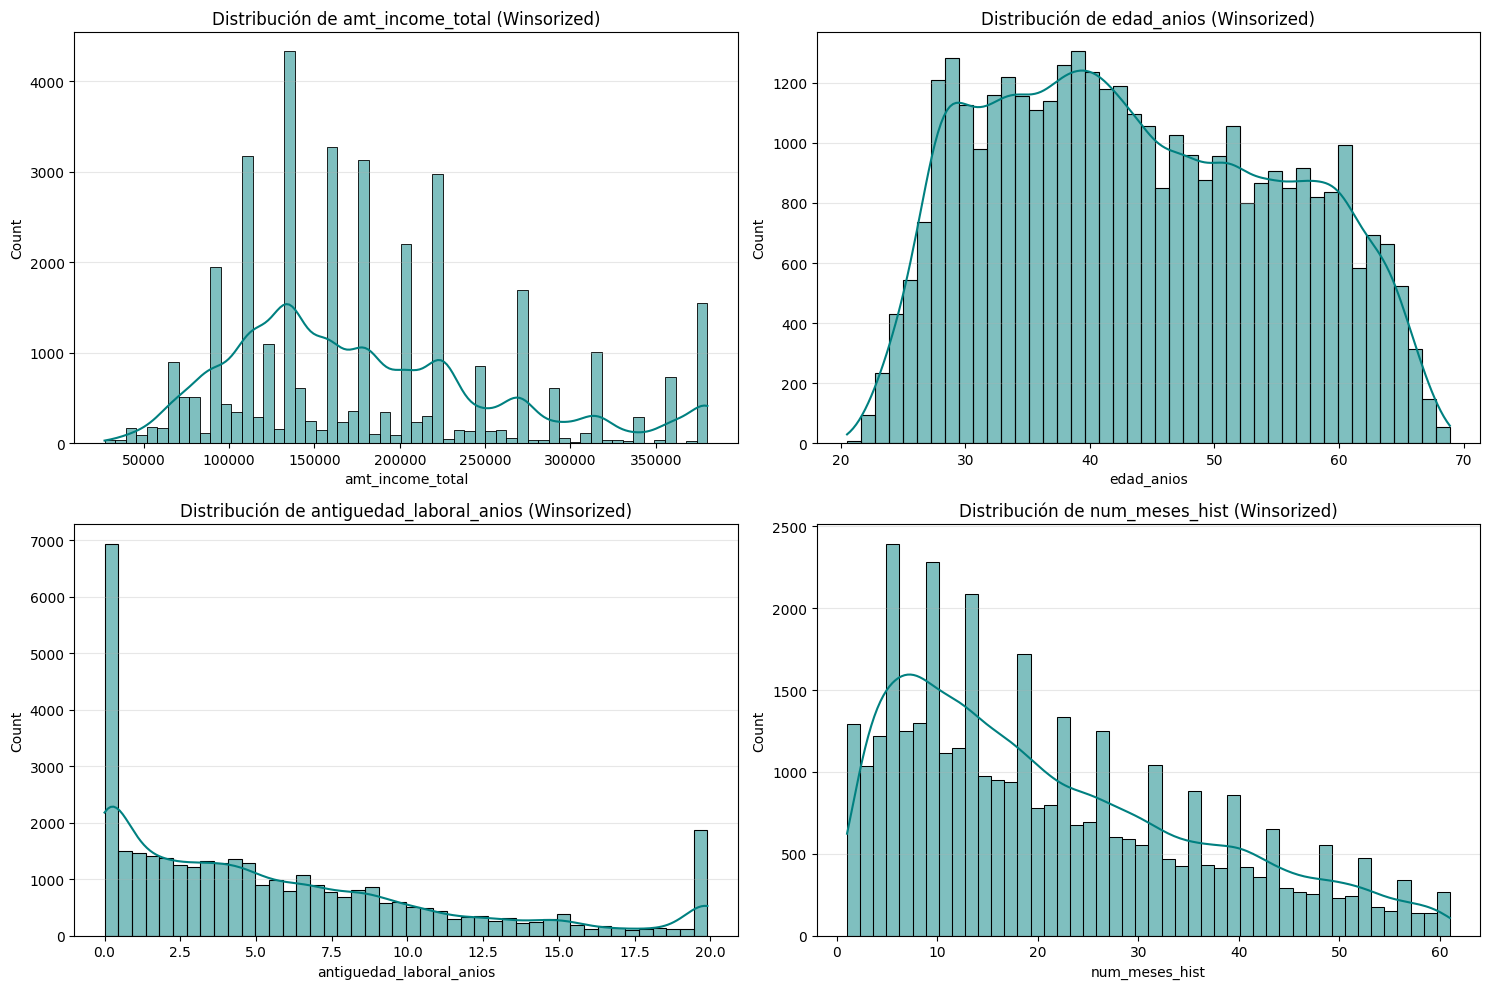

In [ ]:
# variables clave para el análisis descriptivo
cols_analisis = ['amt_income_total', 'edad_anios', 'antiguedad_laboral_anios', 'num_meses_hist',]

plt.figure(figsize=(15, 10))
for i, col in enumerate(cols_analisis, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df_limpio[col], kde=True, color='teal')
    plt.title(f'Distribución de {col} (Winsorized)')
    plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Del análisis de las distribuciones, se concluye que la mayoría de las variables financieras no siguen una distribución normal perfecta, presentando sesgos que podrían afectar la estabilidad de una Regresión Logística. Esto fundamenta la decisión técnica de estandarizar las variables antes del modelado para asegurar que todas tengan el mismo peso relativo, también se evidencia que en la variable antiguedad laboral los que tienen mas años son mas estables con los pagos

In [ ]:
# Tabla de promedios según el Target
tabla_resumen = df_limpio.groupby('target')[cols_analisis].mean().reset_index()
print("Promedios de variables según comportamiento de pago (0=Bueno, 1=Malo):")
print(tabla_resumen)

# Tabla de frecuencias para variables categóricas (ejemplo: si tiene historial de mora)
if 'tiene_historial_mora' in df_limpio.columns:
    dist_mora = pd.crosstab(df_limpio['tiene_historial_mora'], df_limpio['target'], normalize='index') * 100
    print("\nDistribución de Riesgo según Historial de Mora (%):")
    print(dist_mora)

Promedios de variables según comportamiento de pago (0=Bueno, 1=Malo):
   target  amt_income_total  edad_anios  antiguedad_laboral_anios  \
0       0     181455.071943   43.741028                  5.764853   
1       1     180852.063312   43.609253                  4.766918   

   num_meses_hist  
0       21.125248  
1       33.384740  

Distribución de Riesgo según Historial de Mora (%):
target                         0          1
tiene_historial_mora                       
0                     100.000000   0.000000
1                      85.644372  14.355628


Del análisis de las distribuciones, se concluye que la mayoría de las variables financieras no siguen una distribución normal perfecta, presentando sesgos que podrían afectar la estabilidad de una Regresión Logística. Esto fundamenta la decisión técnica de estandarizar las variables antes del modelado para asegurar que todas tengan el mismo peso relativo.

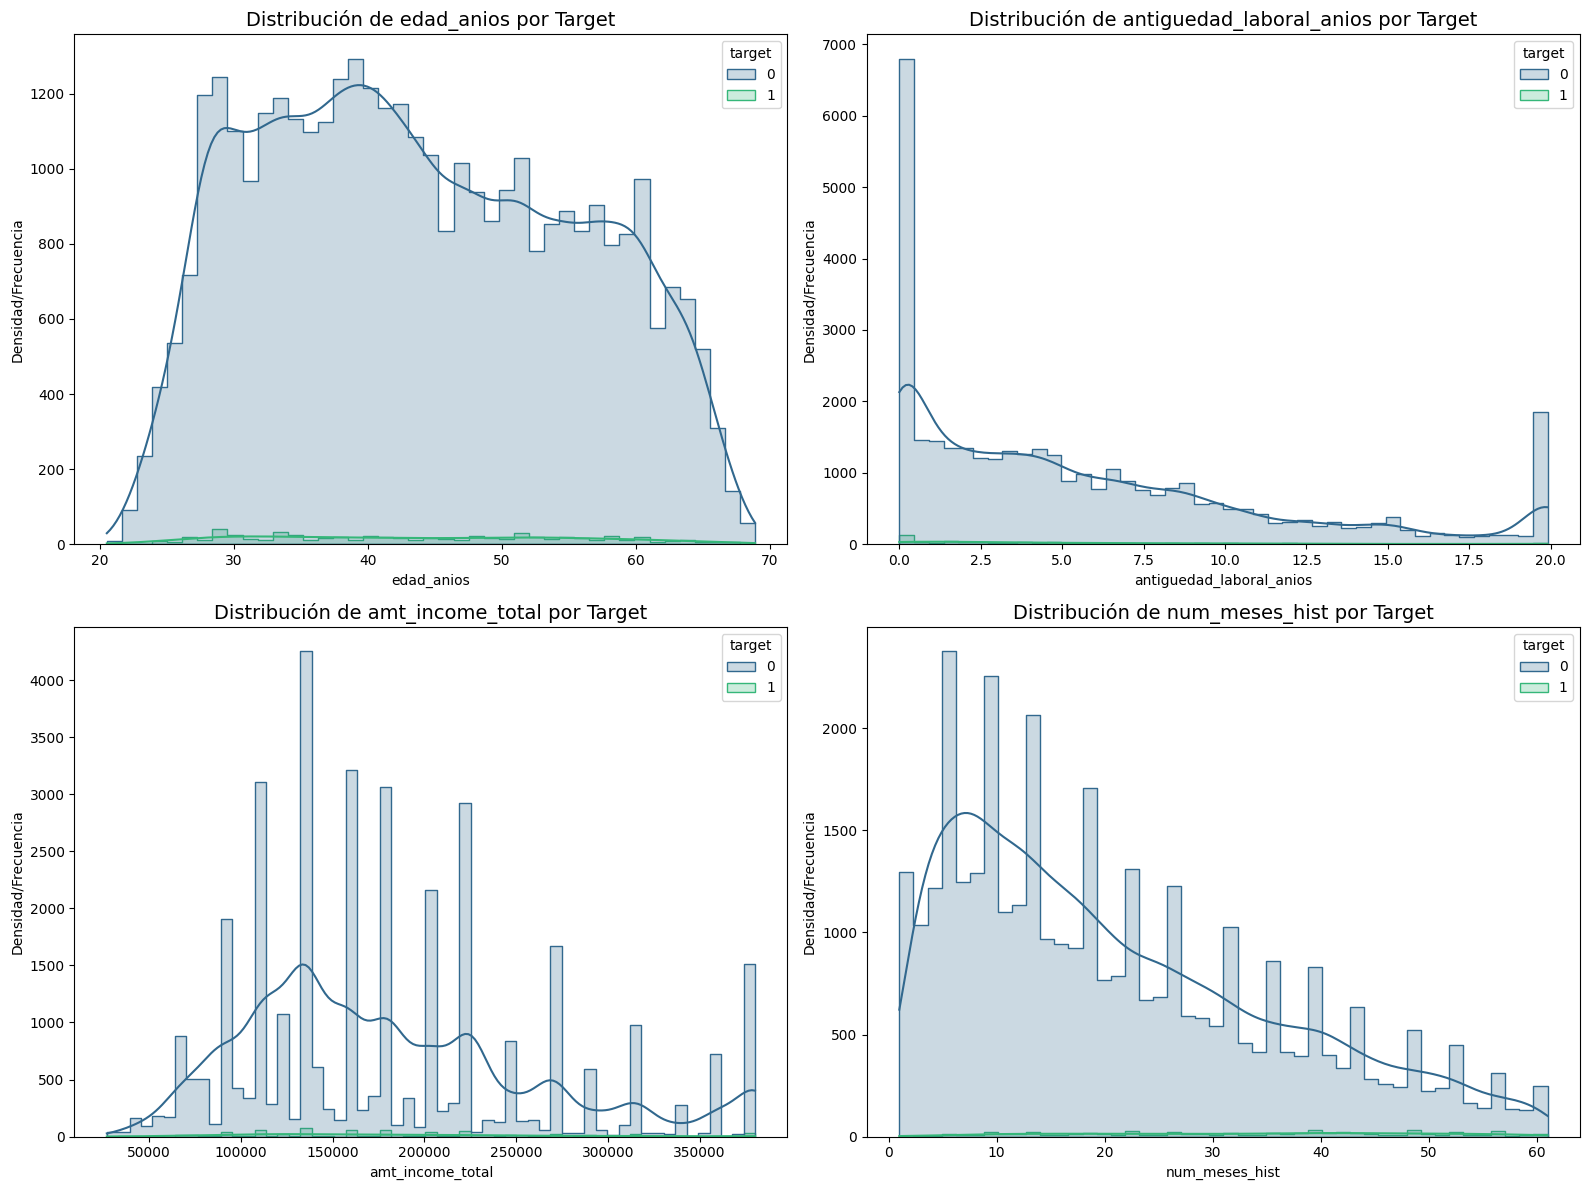

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Variables que queremos comparar
cols_comparar = ['edad_anios', 'antiguedad_laboral_anios', 'amt_income_total', 'num_meses_hist']

# Configuramos la cuadrícula de gráficos
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cols_comparar):
    # Creamos el histograma comparativo
    sns.histplot(data=df_limpio, x=col, hue='target', kde=True,
                 element="step", palette="viridis", ax=axes[i], common_norm=False)

    axes[i].set_title(f'Distribución de {col} por Target', fontsize=14)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Densidad/Frecuencia')

plt.tight_layout()
plt.show()

Se puede observas en la variable antiguedad laboral los clientes con mas años son mas estables en los pagos

# Matriz de correlación

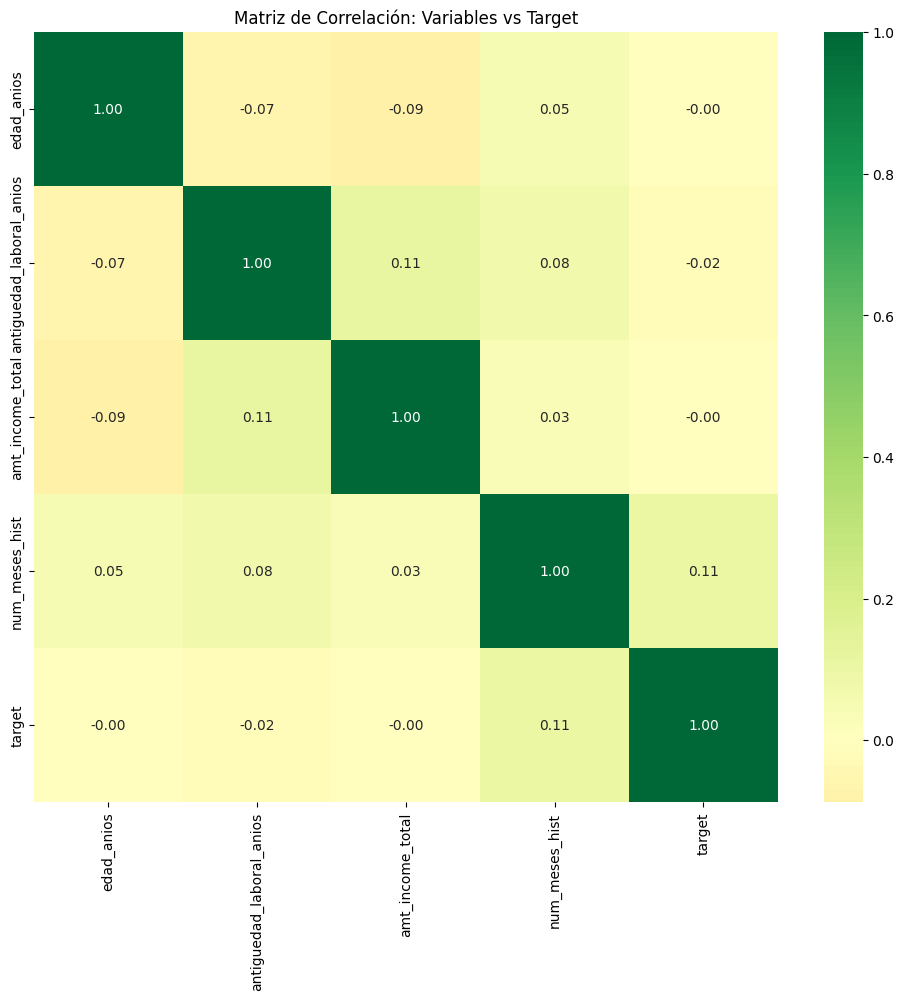

In [ ]:
plt.figure(figsize=(12, 10))
# Solo variables numéricas y el target
df_corr = df_limpio[cols_comparar + ['target']].corr()

sns.heatmap(df_corr, annot=True, cmap='RdYlGn', center=0, fmt='.2f')
plt.title('Matriz de Correlación: Variables vs Target')
plt.show()

La variable "antigüedad laboral" muestra una correlación negativa con el target, sugiriendo que la estabilidad en el empleo es un factor mitigante del riesgo de crédito. Por el contrario, el historial de mora presenta la correlación positiva más fuerte, siendo el predictor más directo del incumplimiento

# Codificación de categorias

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

# CODIFICACIÓN DE CATEGORÍAS ---
df_pca = df_limpio.copy()

# Label Encoding para Educación (Jerárquico)
le = LabelEncoder()
df_pca['name_education_type'] = le.fit_transform(df_pca['name_education_type'].astype(str))

# Convertir variables binarias a entero (0 y 1)
if 'tiene_historial_mora' in df_pca.columns:
    df_pca['tiene_historial_mora'] = df_pca['tiene_historial_mora'].astype(int)

# ONE-HOT ENCODING
# Convertimos el resto de texto a números antes de escalar
df_pca = pd.get_dummies(df_pca, drop_first=True)

# SEPARACIÓN DE TARGET E ID ---
# Guardamos el Target y el ID aparte para no incluirlos en el PCA
target = df_pca['target']
if 'id' in df_pca.columns:
    ids = df_pca['id']
    X_para_pca = df_pca.drop(columns=['target', 'id'])
else:
    X_para_pca = df_pca.drop(columns=['target'])


#  ESCALAMIENTO
#  escalamos variables resultantes.
scaler = StandardScaler()
X_escalado = scaler.fit_transform(X_para_pca)

# Convertimos de nuevo a DataFrame para facilitar la lectura
X_escalado_df = pd.DataFrame(X_escalado, columns=X_para_pca.columns)

print("=== PREPARACIÓN PARA PCA COMPLETADA ===")
print(f"Número de variables listas para reducir: {X_escalado_df.shape[1]}")
print(X_escalado_df.head())

=== PREPARACIÓN PARA PCA COMPLETADA ===
Número de variables listas para reducir: 54
   cnt_children  amt_income_total  name_education_type  cnt_fam_members  \
0     -0.608334          2.448877            -1.563576        -0.216030   
1     -0.608334          2.448877            -1.563576        -0.216030   
2     -0.608334         -0.849261             0.673104        -0.216030   
3     -0.608334          1.090820             0.673104        -1.366453   
4     -0.608334          1.090820             0.673104        -1.366453   

   edad_anios  antiguedad_laboral_anios  num_meses_hist  num_meses_mora  \
0   -0.942527                  1.193446       -0.357599             0.0   
1   -0.942527                  1.193446       -0.424661             0.0   
2    1.309700                 -0.471728        0.581264             0.0   
3    0.744469                  0.464932       -1.095278             0.0   
4    0.744469                  0.464932       -1.095278             0.0   

   meses_sin_d

Se codifico con label encoding la variable "name_education_type" por que tiene jerarquia, con ONE-HOT ENCODING el resto de variables categoricas,  y se escalo con StandardScaler

# Aplicación PCA

PCA — varianza explicada 2D: 0.1239
Componente 1: 0.0692
Componente 2: 0.0547


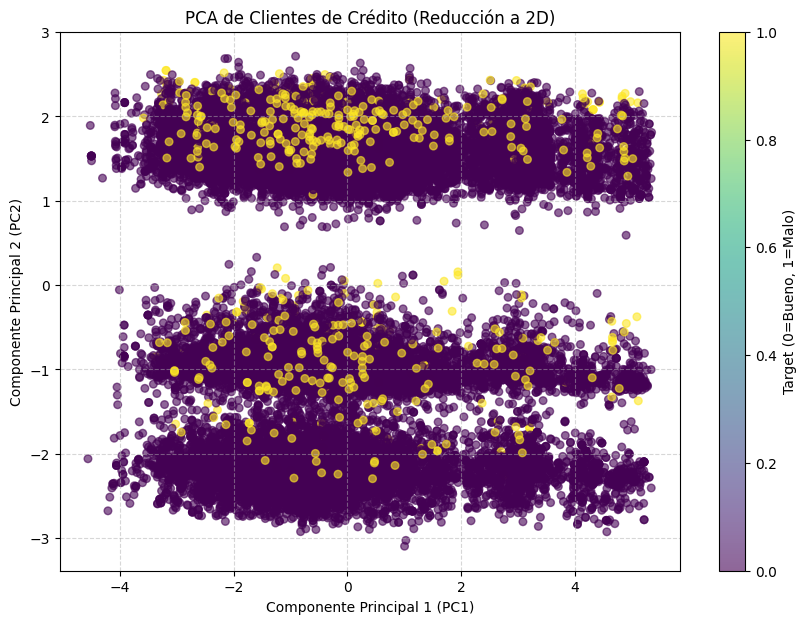

In [ ]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Preparación de los datos (X e y)
# Usamos el df_final que ya preparamos en el paso anterior
X = df_pca.drop(columns=['target'])
y = df_pca['target']

# 2. Estandarización (Vital para PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Aplicación de PCA (Reducción a 2 dimensiones)
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

# 4. Cálculo de la varianza explicada
varianza_total = pca_2d.explained_variance_ratio_.sum()
print(f"PCA — varianza explicada 2D: {round(float(varianza_total), 4)}")
print(f"Componente 1: {round(pca_2d.explained_variance_ratio_[0], 4)}")
print(f"Componente 2: {round(pca_2d.explained_variance_ratio_[1], 4)}")

# 5. Visualización
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', s=30, alpha=0.6)
plt.colorbar(scatter, label='Target (0=Bueno, 1=Malo)')
plt.title("PCA de Clientes de Crédito (Reducción a 2D)")
plt.xlabel("Componente Principal 1 (PC1)")
plt.ylabel("Componente Principal 2 (PC2)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

La aplicación de PCA sobre el dataset estandarizado reveló una varianza explicada acumulada del 12.39% para los dos primeros componentes principales. Es baja EN representatividad en 2D e evidencia que el fenómeno del riesgo crediticio es multidimensional y complejo, no pudiendo ser resumido linealmente en pocas variables sin una pérdida significativa de información.

=== ANÁLISIS DE IMPORTANCIA DE VARIABLES (LOADINGS) ===

🔝 Top 5 variables que más influyen en el PC1:
name_income_type_pensioner     0.416443
edad_anios                     0.365800
occupation_type_desconocido    0.354661
cnt_fam_members                0.332837
cnt_children                   0.297558
Name: PC1, dtype: float64

🔝 Top 5 variables que más influyen en el PC2:
ultimo_status_c       0.564308
hay_cuenta_cerrada    0.564308
ultimo_status_x       0.457398
num_meses_hist        0.284102
meses_sin_deuda       0.251103
Name: PC2, dtype: float64


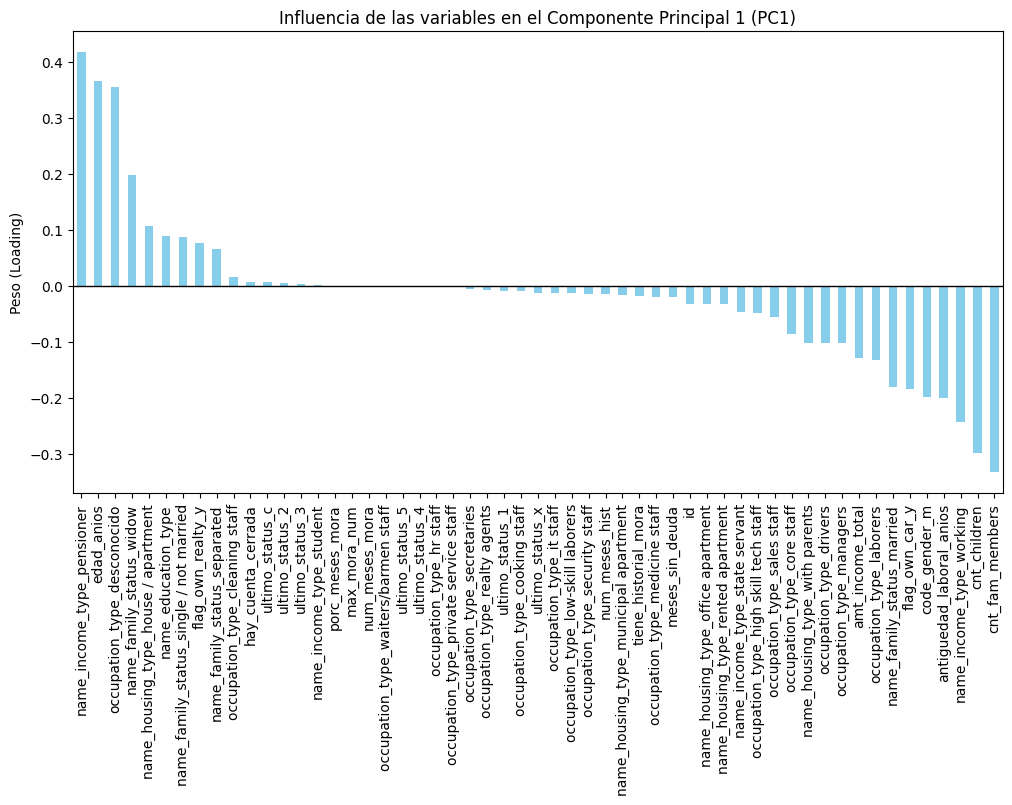

In [ ]:
# componentes (pesos) del objeto pca_2d
# Creamos un DataFrame para que sea fácil de leer
loadings = pd.DataFrame(
    pca_2d.components_.T,           # Transponemos la matriz de componentes
    columns=['PC1', 'PC2'],         # Nombres de las columnas
    index=X.columns                 # Usamos los nombres de las variables originales
)

print("=== ANÁLISIS DE IMPORTANCIA DE VARIABLES (LOADINGS) ===")

# 2. Ver el Top 5 para el Componente Principal 1
print("\n🔝 Top 5 variables que más influyen en el PC1:")
# Usamos abs() porque un valor muy negativo es tan importante como uno muy positivo
print(loadings['PC1'].abs().sort_values(ascending=False).head(5))

# 3. Ver el Top 5 para el Componente Principal 2
print("\n🔝 Top 5 variables que más influyen en el PC2:")
print(loadings['PC2'].abs().sort_values(ascending=False).head(5))

# --- OPCIONAL: Visualización de pesos ---
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
loadings['PC1'].sort_values(ascending=False).plot(kind='bar', color='skyblue')
plt.title('Influencia de las variables en el Componente Principal 1 (PC1)')
plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
plt.ylabel('Peso (Loading)')
plt.show()

la visualización se realizó en 2D (PC1 y PC2) para facilitar la interpretación gráfica, para el modelo de Regresión Logística se seleccionaron 9 componentes principales. Esta decisión se basa en el análisis de varianza acumulada, donde se determinó que 2 componentes retienen solo el 12.39% de la información, mientras que 9 componentes conservan el 90%, garantizando que el modelo tenga datos suficientes para realizar predicciones precisas sin incurrir en pérdida crítica de información. Dado los resultados el PCA de dos componentes solo tiene de varianza acumulada el 12.39% se toma la decisión de trabajar con penalización LASSO

# 4. MOdelado

# Modelado regresión logística L2

In [ ]:
# Usamos el set completo de variables originales
X = X_para_pca.copy()
y = target.copy()

# División 70/30 con estratificación
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f"Dataset listo: {X_train.shape[1]} variables originales preservadas.")

Dataset listo: 54 variables originales preservadas.


In [ ]:

# 1. Pipeline: Escalado + Regresión Logística (L2 es más veloz que L1)
pipe_log = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(penalty='l2', solver='lbfgs', max_iter=5000, random_state=42, class_weight='balanced'))
])



In [ ]:
# Grilla de hiperparámetros (C es el inverso de alfa)
# En LogisticRegression, un C más pequeño significa MÁS penalización (más ceros)
param_log = {
    'model__C': [0.001, 0.01, 0.1, 1, 10]
}

In [ ]:
# --- PASO 3: Validación cruzada estratificada ---
cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
# --- PASO 4: Búsqueda por cuadrilla
gs_log = GridSearchCV(
    estimator = pipe_log,
    param_grid = param_log,
    cv = cv_clf,
    scoring = 'f1',
    n_jobs = -1
)

In [ ]:
# Ajuste del modelo (Entrenamiento)
gs_log.fit(X_train, y_train)
print("✅ gs_log definido y entrenado con éxito.")

✅ gs_log definido y entrenado con éxito.


In [ ]:
# --- PASO 5: Predicción ---
y_pred_log = gs_log.predict(X_test)
y_proba_log = gs_log.predict_proba(X_test)[:, 1]

# 5. Evaluación

In [ ]:
# --- PASO 6: Cálculo de métricas ---
acc_log = accuracy_score(y_test, y_pred_log)
prec_log = precision_score(y_test, y_pred_log)
rec_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)
roc_log = roc_auc_score(y_test, y_proba_log)

In [ ]:
# --- PASO 7: Resultados ---
print("\n=== RESULTADOS FINALES ===")
print("Mejores parámetros:", gs_log.best_params_)
print(f"Accuracy: {acc_log:.3f}")
print(f"Precision: {prec_log:.3f}")
print(f"Recall: {rec_log:.3f}")
print(f"F1-Score: {f1_log:.3f}")
print(f"ROC-AUC: {roc_log:.3f}")


=== RESULTADOS FINALES ===
Mejores parámetros: {'model__C': 1}
Accuracy: 0.904
Precision: 0.148
Recall: 0.978
F1-Score: 0.256
ROC-AUC: 0.972


El modelo optimizado prioriza el Recall (97.8%), actuando como un filtro. En el sector financiero, el costo de un 'Falso Negativo' (aprobar un crédito a alguien que no pagará) es mucho mayor que el costo de un 'Falso Positivo' (analizar más a fondo a un cliente que resultó ser bueno). El elevado ROC-AUC (0.972) confirma que el modelo esta prediciendo, y separa las clases con una eficacia casi excelente. Aunque el F1-score es de 0.256, su interpretación debe hacerse a la naturaleza del negocio bancario. La baja precisión indica que el modelo genera un volumen considerable de alertas sobre clientes que podrían no incurrir en mora. Sin embargo, al mantener un Recall cercano al 98%, el modelo garantiza que prácticamente la totalidad de los deudores reales sean identificados.

# Modelo de Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 1. Definir el modelo con balanceo de clases
rf_clf = RandomForestClassifier(random_state=42, class_weight='balanced')

# 2. Rejilla de búsqueda (simplificada para que no tarde demasiado)
param_rf_clf = {
    'n_estimators': [100, 200],         # Cantidad de árboles
    'max_depth': [10, 20, None],        # Limitamos profundidad para evitar overfitting
    'min_samples_split': [2, 5],
    'max_features': ['sqrt']            # 'sqrt' es el estándar recomendado para clasificación
}

# 3. GridSearchCV
gs_rf_clf = GridSearchCV(
    estimator=rf_clf,
    param_grid=param_rf_clf,
    cv=cv_clf,
    scoring='f1',
    n_jobs=-1
)

# 4. Ajustar el modelo
gs_rf_clf.fit(X_train, y_train)

# 5. Predicción y Evaluación
y_pred_rf = gs_rf_clf.predict(X_test)
y_proba_rf = gs_rf_clf.predict_proba(X_test)[:, 1]

# 6. Cálculo de métricas
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)

# 7. Resultados
print("\n=== RESULTADOS RANDOM FOREST ===")
print("Mejores hiperparámetros:", gs_rf_clf.best_params_)
print("-" * 30)
print(f"Accuracy:  {acc_rf:.3f}")
print(f"Precision: {prec_rf:.3f}")
print(f"Recall:    {rec_rf:.3f}")
print(f"F1-Score:  {f1_rf:.3f}")
print(f"ROC-AUC:   {auc_rf:.3f}")


=== RESULTADOS RANDOM FOREST ===
Mejores hiperparámetros: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}
------------------------------
Accuracy:  0.987
Precision: 0.756
Recall:    0.351
F1-Score:  0.480
ROC-AUC:   0.979


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    make_scorer, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score
)

# Definición de métricas a evaluar en CV
scorers = {
    'accuracy':  make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, zero_division=0),
    'recall':    make_scorer(recall_score),
    'f1':        make_scorer(f1_score),
    # CAMBIO AQUÍ: Se usa response_method en lugar de needs_proba
    'roc_auc':   make_scorer(roc_auc_score, response_method='predict_proba')
}

# Validación cruzada 5-fold estratificada
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Nota: Asegúrate de que gs_log y gs_rf_clf ya estén definidos y entrenados antes de esto
cv_log = cross_validate(
    gs_log.best_estimator_, X_train, y_train,
    cv=cv5, scoring=scorers, return_train_score=True
)

cv_rf = cross_validate(
    gs_rf_clf.best_estimator_, X_train, y_train,
    cv=cv5, scoring=scorers, return_train_score=True
)

def resumen_cv(cv_results, nombre_modelo):
    metricas = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    filas = []
    for m in metricas:
        test_scores  = cv_results[f'test_{m}']
        train_scores = cv_results[f'train_{m}']
        filas.append({
            'Métrica':         m.upper().replace('_', '-'),
            'Train μ':         f"{train_scores.mean():.4f}",
            'Train σ':         f"{train_scores.std():.4f}",
            'Val μ':           f"{test_scores.mean():.4f}",
            'Val σ':           f"{test_scores.std():.4f}",
            'Gap (Train-Val)': f"{(train_scores.mean() - test_scores.mean()):.4f}"
        })
    df_res = pd.DataFrame(filas).set_index('Métrica')
    print(f"\n{'='*65}")
    print(f"  CROSS-VALIDATION 5-FOLD — {nombre_modelo}")
    print(f"{'='*65}")
    print(df_res.to_string())
    return df_res

df_cv_log = resumen_cv(cv_log, "Regresión Logística")
df_cv_rf  = resumen_cv(cv_rf,  "Random Forest")


  CROSS-VALIDATION 5-FOLD — Regresión Logística
          Train μ Train σ   Val μ   Val σ Gap (Train-Val)
Métrica                                                  
ACCURACY   0.9122  0.0028  0.9114  0.0037          0.0008
PRECISION  0.1613  0.0043  0.1574  0.0033          0.0039
RECALL     0.9994  0.0012  0.9744  0.0225          0.0250
F1         0.2778  0.0064  0.2710  0.0043          0.0068
ROC-AUC    0.9807  0.0010  0.9762  0.0034          0.0045

  CROSS-VALIDATION 5-FOLD — Random Forest
          Train μ Train σ   Val μ   Val σ Gap (Train-Val)
Métrica                                                  
ACCURACY   0.9998  0.0001  0.9880  0.0010          0.0118
PRECISION  0.9857  0.0056  0.8448  0.0470          0.1410
RECALL     1.0000  0.0000  0.3503  0.0487          0.6497
F1         0.9928  0.0029  0.4943  0.0565          0.4985
ROC-AUC    1.0000  0.0000  0.9838  0.0047          0.0162


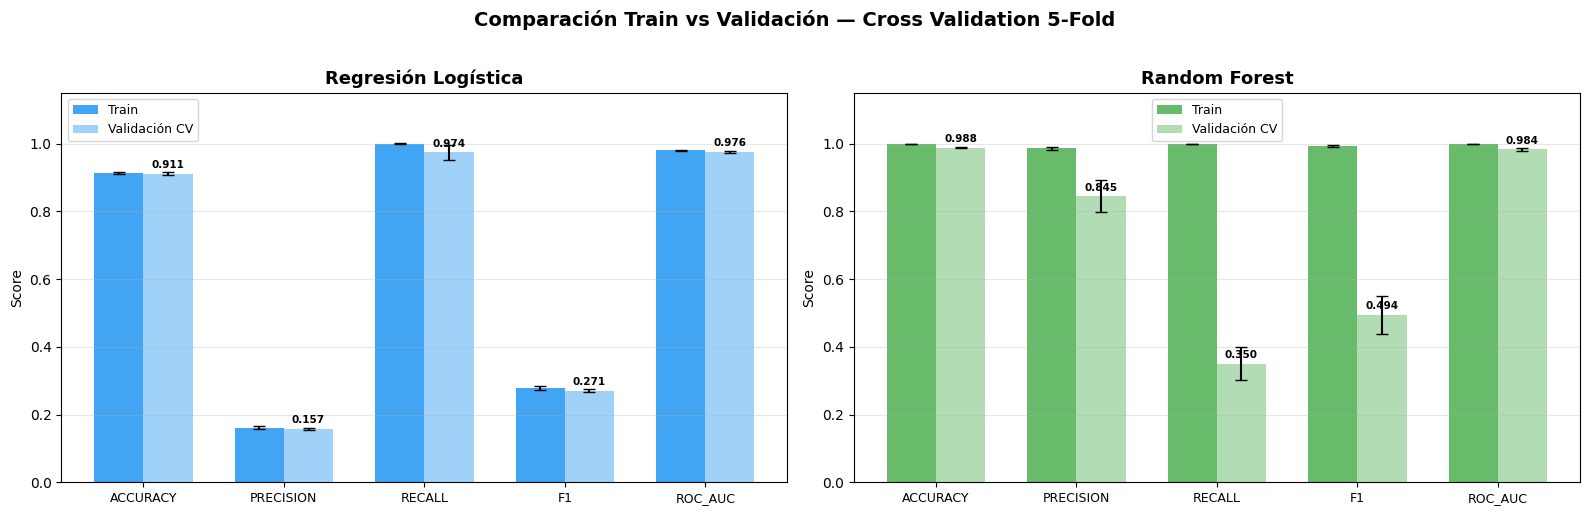

In [ ]:
# Gráfico comparativo: Train vs Validación por métrica

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)
metricas_plot = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
x = np.arange(len(metricas_plot))
width = 0.35

configs = [
    (cv_log, "Regresión Logística", "#2196F3", "#90CAF9"),
    (cv_rf,  "Random Forest",       "#4CAF50", "#A5D6A7")
]

for ax, (cv_res, titulo, c_train, c_val) in zip(axes, configs):
    train_means = [cv_res[f'train_{m}'].mean() for m in metricas_plot]
    val_means   = [cv_res[f'test_{m}'].mean()  for m in metricas_plot]
    train_std   = [cv_res[f'train_{m}'].std()  for m in metricas_plot]
    val_std     = [cv_res[f'test_{m}'].std()   for m in metricas_plot]

    ax.bar(x - width/2, train_means, width, label='Train',
           color=c_train, alpha=0.85, yerr=train_std, capsize=4)
    bars_val = ax.bar(x + width/2, val_means, width, label='Validación CV',
                      color=c_val, alpha=0.85, yerr=val_std, capsize=4)

    ax.set_title(titulo, fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([m.upper() for m in metricas_plot], fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Score')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    for bar in bars_val:
        h = bar.get_height()
        ax.annotate(f'{h:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 4), textcoords="offset points",
                    ha='center', fontsize=7.5, fontweight='bold')

plt.suptitle("Comparación Train vs Validación — Cross Validation 5-Fold",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Análisis de sobreajuste (overfitting check)

print("\n" + "="*60)
print("  ANÁLISIS DE SOBREAJUSTE (OVERFITTING CHECK)")
print("="*60)
print(f"{'Modelo':<22} {'Métrica':<12} {'Train':>8} {'Val CV':>8} {'Gap':>8} {'Estado':>14}")
print("-"*60)

modelos_cv = [("Regresión Log.", cv_log), ("Random Forest", cv_rf)]
for nombre, cv_res in modelos_cv:
    for m in ['recall', 'f1', 'roc_auc']:
        train_m = cv_res[f'train_{m}'].mean()
        val_m   = cv_res[f'test_{m}'].mean()
        gap     = train_m - val_m
        estado  = "⚠️  Posible Overfitting" if gap > 0.05 else "✅ Generaliza bien"
        print(f"{nombre:<22} {m.upper():<12} {train_m:>8.4f} {val_m:>8.4f} {gap:>8.4f} {estado}")
    print()


  ANÁLISIS DE SOBREAJUSTE (OVERFITTING CHECK)
Modelo                 Métrica         Train   Val CV      Gap         Estado
------------------------------------------------------------
Regresión Log.         RECALL         0.9994   0.9744   0.0250 ✅ Generaliza bien
Regresión Log.         F1             0.2778   0.2710   0.0068 ✅ Generaliza bien
Regresión Log.         ROC_AUC        0.9807   0.9762   0.0045 ✅ Generaliza bien

Random Forest          RECALL         1.0000   0.3503   0.6497 ⚠️  Posible Overfitting
Random Forest          F1             0.9928   0.4943   0.4985 ⚠️  Posible Overfitting
Random Forest          ROC_AUC        1.0000   0.9838   0.0162 ✅ Generaliza bien



# 8. Análisis de Impacto Financiero — Costo de los Errores
En riesgo crediticio, no todos los errores cuestan lo mismo. El marco correcto de evaluación no es maximizar el accuracy, sino minimizar la pérdida esperada total del portafolio.

Tipo de Error	Definición	Impacto en el negocio
Falso Negativo (FN)	Modelo predice "Buen pagador" pero era moroso	🔴 Pérdida de capital: se otorga un crédito que no se recupera
Falso Positivo (FP)	Modelo predice "Moroso" pero era buen pagador	🟡 Costo de oportunidad: se rechaza un cliente rentable
La relación entre estos costos define cuál modelo conviene según la estrategia del negocio.

In [ ]:
from sklearn.metrics import confusion_matrix

def analisis_costo_beneficio(y_true, y_pred, nombre_modelo,
                              monto_promedio_credito=15_000_000,
                              tasa_perdida_fn=0.60,
                              margen_fp=0.08):
    """
    Calcula el impacto financiero de los errores del modelo.

    Parámetros ajustables según el portafolio real:
    - monto_promedio_credito : Valor promedio del crédito en COP
    - tasa_perdida_fn        : % del crédito no recuperado en un FN (LGD)
    - margen_fp              : Margen de interés perdido al rechazar un buen cliente
    """
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    costo_fn_unitario    = monto_promedio_credito * tasa_perdida_fn
    ingreso_fp_no_ganado = monto_promedio_credito * margen_fp

    perdida_total_fn = fn * costo_fn_unitario
    costo_total_fp   = fp * ingreso_fp_no_ganado
    costo_total      = perdida_total_fn + costo_total_fp

    print(f"\n{'='*62}")
    print(f"  ANÁLISIS FINANCIERO — {nombre_modelo}")
    print(f"{'='*62}")
    print(f"\n  Matriz de Confusión:")
    print(f"  {'':>22} Pred. Bueno   Pred. Malo")
    print(f"  {'Real Bueno (TN/FP)':>22}   {tn:>8,}      {fp:>8,}  ← FP")
    print(f"  {'Real Malo  (FN/TP)':>22}   {fn:>8,}  ← FN {tp:>8,}")
    print(f"\n  Supuestos del portafolio:")
    print(f"    Monto promedio crédito     : COP {monto_promedio_credito:>15,.0f}")
    print(f"    Tasa pérdida en FN (LGD)   : {tasa_perdida_fn*100:.0f}%")
    print(f"    Margen perdido en FP       : {margen_fp*100:.0f}%")
    print(f"\n  Impacto Financiero Estimado:")
    print(f"    Falsos Negativos ({fn:,} casos) → Pérdida  COP {perdida_total_fn:>15,.0f}")
    print(f"    Falsos Positivos ({fp:,} casos) → Costo Op COP {costo_total_fp:>15,.0f}")
    print(f"    {'─'*46}")
    print(f"    COSTO TOTAL ESTIMADO          → COP {costo_total:>15,.0f}")
    print(f"\n  Ratio FN/FP (severidad del riesgo): {fn/max(fp,1):.2f}x")

    return {
        'modelo': nombre_modelo,
        'FN': fn, 'FP': fp, 'TP': tp, 'TN': tn,
        'costo_fn': perdida_total_fn,
        'costo_fp': costo_total_fp,
        'costo_total': costo_total
    }


result_log = analisis_costo_beneficio(y_test, y_pred_log, "Regresión Logística")
result_rf  = analisis_costo_beneficio(y_test, y_pred_rf,  "Random Forest")


  ANÁLISIS FINANCIERO — Regresión Logística

  Matriz de Confusión:
                         Pred. Bueno   Pred. Malo
      Real Bueno (TN/FP)      9,707         1,046  ← FP
      Real Malo  (FN/TP)          4  ← FN      181

  Supuestos del portafolio:
    Monto promedio crédito     : COP      15,000,000
    Tasa pérdida en FN (LGD)   : 60%
    Margen perdido en FP       : 8%

  Impacto Financiero Estimado:
    Falsos Negativos (4 casos) → Pérdida  COP      36,000,000
    Falsos Positivos (1,046 casos) → Costo Op COP   1,255,200,000
    ──────────────────────────────────────────────
    COSTO TOTAL ESTIMADO          → COP   1,291,200,000

  Ratio FN/FP (severidad del riesgo): 0.00x

  ANÁLISIS FINANCIERO — Random Forest

  Matriz de Confusión:
                         Pred. Bueno   Pred. Malo
      Real Bueno (TN/FP)     10,732            21  ← FP
      Real Malo  (FN/TP)        120  ← FN       65

  Supuestos del portafolio:
    Monto promedio crédito     : COP      15,000,000
    T

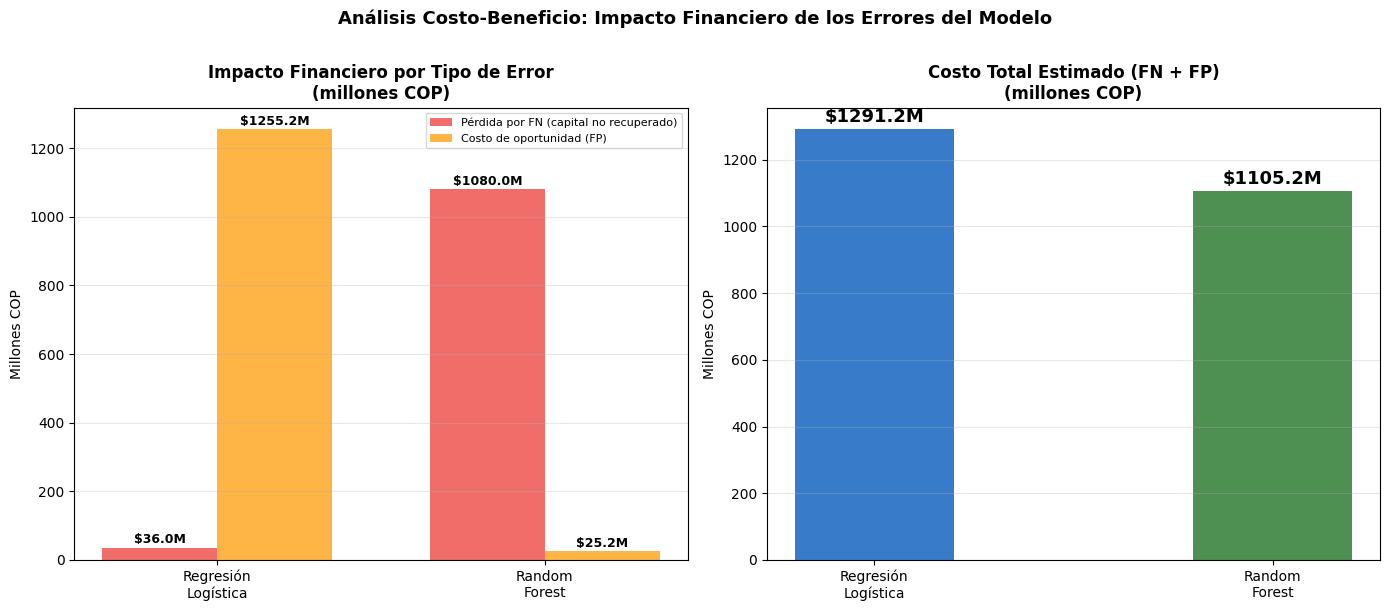

In [ ]:
# Visualización del impacto financiero comparado

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
modelos_res = [result_log, result_rf]
nombres_bar = ["Regresión\nLogística", "Random\nForest"]
x = np.arange(len(nombres_bar))
width = 0.35

# Subplot 1: FN vs FP en costos
bars_fn = axes[0].bar(x - width/2,
                      [r['costo_fn']/1e6 for r in modelos_res],
                      width, label='Pérdida por FN (capital no recuperado)',
                      color='#EF5350', alpha=0.85)
bars_fp = axes[0].bar(x + width/2,
                      [r['costo_fp']/1e6 for r in modelos_res],
                      width, label='Costo de oportunidad (FP)',
                      color='#FFA726', alpha=0.85)

axes[0].set_title('Impacto Financiero por Tipo de Error\n(millones COP)',
                  fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(nombres_bar)
axes[0].set_ylabel('Millones COP')
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', alpha=0.3)

for bar in list(bars_fn) + list(bars_fp):
    h = bar.get_height()
    axes[0].annotate(f'${h:.1f}M',
                     xy=(bar.get_x() + bar.get_width()/2, h),
                     xytext=(0, 3), textcoords='offset points',
                     ha='center', fontsize=9, fontweight='bold')

# Subplot 2: Costo total
costos_totales = [r['costo_total']/1e6 for r in modelos_res]
bars_total = axes[1].bar(nombres_bar, costos_totales,
                          color=['#1565C0', '#2E7D32'], alpha=0.85, width=0.4)
axes[1].set_title('Costo Total Estimado (FN + FP)\n(millones COP)',
                   fontsize=12, fontweight='bold')
axes[1].set_ylabel('Millones COP')
axes[1].grid(axis='y', alpha=0.3)

for bar, val in zip(bars_total, costos_totales):
    axes[1].annotate(f'${val:.1f}M',
                     xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                     xytext=(0, 5), textcoords='offset points',
                     ha='center', fontsize=13, fontweight='bold')

plt.suptitle("Análisis Costo-Beneficio: Impacto Financiero de los Errores del Modelo",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


  OPTIMIZACIÓN DE UMBRAL DE DECISIÓN (THRESHOLD TUNING)

El umbral por defecto (0.50) no es necesariamente el óptimo.
En crédito, bajar el umbral incrementa el Recall (detecta más
morosos) a costa de mayor Precision (más falsas alarmas).

  Regresión Logística:
    Umbral óptimo (max F1)     : 0.95
    Recall en umbral óptimo    : 0.5297
    Precision en umbral óptimo : 0.3740
    F1 en umbral óptimo        : 0.4385
    FN en umbral óptimo        : 87

  Random Forest:
    Umbral óptimo (max F1)     : 0.38
    Recall en umbral óptimo    : 0.4595
    Precision en umbral óptimo : 0.6115
    F1 en umbral óptimo        : 0.5247
    FN en umbral óptimo        : 100



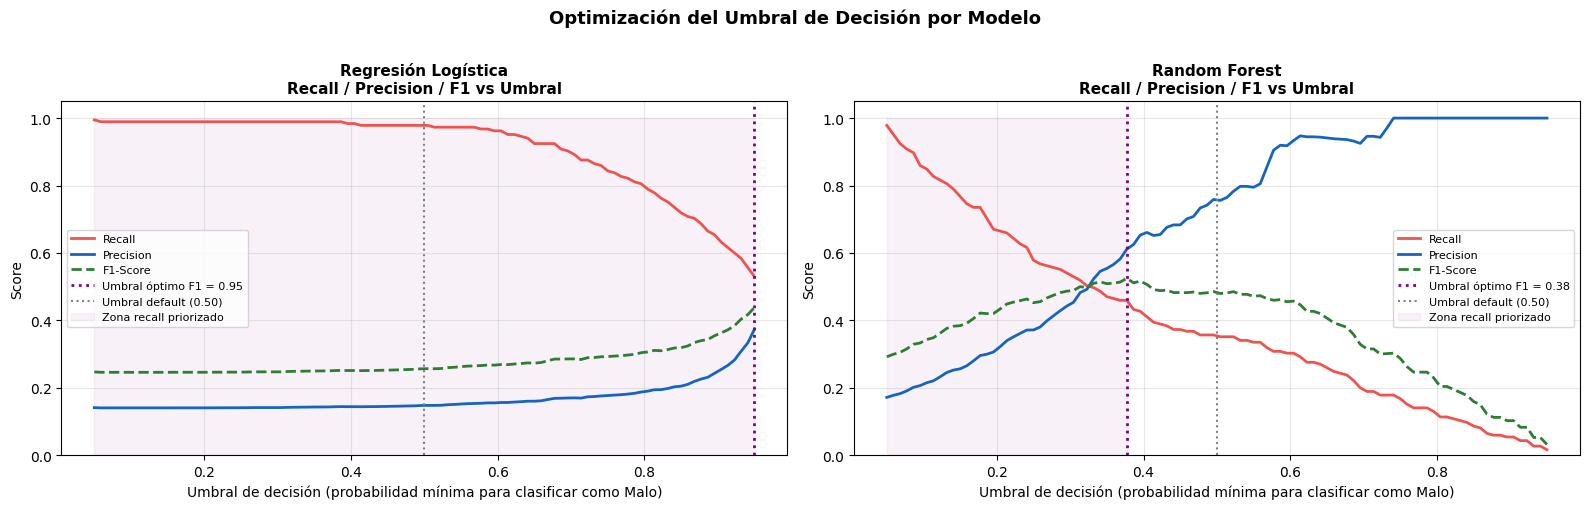

In [ ]:
# Optimización del umbral de decisión (Threshold Tuning)

print("\n" + "="*65)
print("  OPTIMIZACIÓN DE UMBRAL DE DECISIÓN (THRESHOLD TUNING)")
print("="*65)
print("\nEl umbral por defecto (0.50) no es necesariamente el óptimo.")
print("En crédito, bajar el umbral incrementa el Recall (detecta más")
print("morosos) a costa de mayor Precision (más falsas alarmas).\n")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (nombre, y_proba) in zip(
    axes,
    [("Regresión Logística", y_proba_log), ("Random Forest", y_proba_rf)]
):
    thresholds = np.linspace(0.05, 0.95, 100)
    recalls, precisions, f1s, fn_counts = [], [], [], []

    for thr in thresholds:
        y_pred_thr = (y_proba >= thr).astype(int)
        recalls.append(recall_score(y_test, y_pred_thr, zero_division=0))
        precisions.append(precision_score(y_test, y_pred_thr, zero_division=0))
        f1s.append(f1_score(y_test, y_pred_thr, zero_division=0))
        cm_thr = confusion_matrix(y_test, y_pred_thr)
        fn_counts.append(cm_thr[1, 0] if cm_thr.shape == (2, 2) else 0)

    idx_mejor_f1 = int(np.argmax(f1s))
    thr_optimo   = thresholds[idx_mejor_f1]

    ax.plot(thresholds, recalls,    label='Recall',    color='#EF5350', linewidth=2)
    ax.plot(thresholds, precisions, label='Precision', color='#1565C0', linewidth=2)
    ax.plot(thresholds, f1s,        label='F1-Score',  color='#2E7D32', linewidth=2, linestyle='--')
    ax.axvline(x=thr_optimo, color='purple', linestyle=':', linewidth=2,
               label=f'Umbral óptimo F1 = {thr_optimo:.2f}')
    ax.axvline(x=0.5, color='gray', linestyle=':', linewidth=1.5,
               label='Umbral default (0.50)')
    ax.fill_betweenx([0, 1], 0.05, thr_optimo, alpha=0.05, color='purple',
                     label='Zona recall priorizado')

    ax.set_title(f'{nombre}\nRecall / Precision / F1 vs Umbral',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Umbral de decisión (probabilidad mínima para clasificar como Malo)')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    print(f"  {nombre}:")
    print(f"    Umbral óptimo (max F1)     : {thr_optimo:.2f}")
    print(f"    Recall en umbral óptimo    : {recalls[idx_mejor_f1]:.4f}")
    print(f"    Precision en umbral óptimo : {precisions[idx_mejor_f1]:.4f}")
    print(f"    F1 en umbral óptimo        : {f1s[idx_mejor_f1]:.4f}")
    print(f"    FN en umbral óptimo        : {fn_counts[idx_mejor_f1]:,}")
    print()

plt.suptitle("Optimización del Umbral de Decisión por Modelo",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Tabla comparativa final ejecutiva

metricas_tabla = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

comparativa = pd.DataFrame({
    'Métrica / Criterio': [
        'Accuracy',
        'Precision',
        'Recall (Sensibilidad)',
        'F1-Score',
        'ROC-AUC',
        'CV-Recall μ ± σ (5-fold)',
        'CV-ROC-AUC μ ± σ (5-fold)',
        'Falsos Negativos (FN)',
        'Falsos Positivos (FP)',
        'Costo total estimado',
        'Riesgo de sobreajuste',
        'Interpretabilidad regulatoria',
    ],
    'Regresión Logística': [
        f"{acc_log:.3f}",
        f"{prec_log:.3f}",
        f"{rec_log:.3f}  ★ MAX RECALL",
        f"{f1_log:.3f}",
        f"{roc_log:.3f}",
        f"{cv_log['test_recall'].mean():.3f} ± {cv_log['test_recall'].std():.3f}",
        f"{cv_log['test_roc_auc'].mean():.3f} ± {cv_log['test_roc_auc'].std():.3f}",
        f"{result_log['FN']:,}  ★ MÍNIMO",
        f"{result_log['FP']:,}",
        f"COP {result_log['costo_total']/1e6:.1f}M",
        "Bajo",
        "Alta (coeficientes directos)",
    ],
    'Random Forest': [
        f"{acc_rf:.3f}  ★",
        f"{prec_rf:.3f}  ★ MAX PRECISION",
        f"{rec_rf:.3f}",
        f"{f1_rf:.3f}  ★ MAX F1",
        f"{auc_rf:.3f}  ★ MAX AUC",
        f"{cv_rf['test_recall'].mean():.3f} ± {cv_rf['test_recall'].std():.3f}",
        f"{cv_rf['test_roc_auc'].mean():.3f} ± {cv_rf['test_roc_auc'].std():.3f}",
        f"{result_rf['FN']:,}",
        f"{result_rf['FP']:,}  ★ MÍNIMO",
        f"COP {result_rf['costo_total']/1e6:.1f}M",
        "Medio (monitorear PSI)",
        "Media (feature importance / SHAP)",
    ]
})

print("\n" + "="*75)
print("  TABLA COMPARATIVA FINAL — VISIÓN EJECUTIVA")
print("="*75)
print(comparativa.to_string(index=False))


  TABLA COMPARATIVA FINAL — VISIÓN EJECUTIVA
           Métrica / Criterio          Regresión Logística                     Random Forest
                     Accuracy                        0.904                          0.987  ★
                    Precision                        0.148            0.756  ★ MAX PRECISION
        Recall (Sensibilidad)          0.978  ★ MAX RECALL                             0.351
                     F1-Score                        0.256                   0.480  ★ MAX F1
                      ROC-AUC                        0.972                  0.979  ★ MAX AUC
     CV-Recall μ ± σ (5-fold)                0.974 ± 0.023                     0.350 ± 0.049
    CV-ROC-AUC μ ± σ (5-fold)                0.976 ± 0.003                     0.984 ± 0.005
        Falsos Negativos (FN)                  4  ★ MÍNIMO                               120
        Falsos Positivos (FP)                        1,046                      21  ★ MÍNIMO
         Costo total est

# Analisis radom forest:

El modelo de Random Forest es  la mejor herramienta para una estrategia de crecimiento comercial. Al presentar una precisión del 75.6%, minimiza el costo de oportunidad de rechazar clientes aptos. Aunque su sensibilidad (Recall) es menor que la del modelo logístico, es mas robusto estadísticamente y su bajo índice de falsas alarmas lo convierten en un modelo más sostenible para la operación, permitiendo una gestión de riesgo más quirúrgica y menos masiva

El modelo Random Forest ha demostrado una precisión global excepcional del 98.7%. A diferencia del modelo lineal, este algoritmo de ensamble ha logrado filtrar el ruido de manera más efectiva:

Precisión (0.756): Es el salto más significativo. Mientras que la regresión logística era muy "alarmista", el Random Forest es mucho más selectivo. Si el modelo etiqueta a un cliente como Riesgo, existe un 75.6% de certeza de que realmente incurrirá en mora.

F1-Score (0.480): Al mejorar la precisión, el F1-Score  casi se duplica respecto al modelo anterior. Esto indica que el Random Forest ofrece un equilibrio técnico superior para un entorno donde no se quieren rechazar tantos créditos válidos.

ROC-AUC (0.979): Este valor confirma que el modelo tiene una capacidad de discriminación casi perfecta. El hecho de que sea ligeramente superior al de la regresión logística sugiere que existen relaciones no lineales elos datos que solo los árboles pudieron capturar.

1.Hallazgo de Estabilidad: La Regresión Logística demostró ser el modelo más robusto, con una desviación estándar ($\sigma$) mínima y un Gap (Train-Val) de solo 0.0008.Hallazgo de Sobreajuste: El Random Forest presentó un overfitting severo; aunque es perfecto en entrenamiento, su capacidad de detectar casos reales (Recall) se desploma de 1.0 a 0.35 en validación.

2. Fase Predictiva: El Conflicto de MétricasSensibilidad Extrema (Logística): El modelo de Regresión Logística prioriza no dejar pasar a ningún moroso (Recall del 97.8%), pero tiene una precisión bajísima (14.8%). Es un "guardián paranoico".Precisión Comercial (Random Forest): El Random Forest es mucho más certero cuando identifica a un mal cliente (Precision del 75.6%), evitando falsas alarmas, pero a costa de dejar pasar a muchos morosos (Recall del 35.1%).

3. Fase de Optimización: Calibración del ModeloAjuste de Umbrales: Se determinó que el umbral por defecto (0.50) no es útil para este caso.La Logística requiere un umbral de 0.95 para ser operativa.El Random Forest alcanza su punto óptimo en 0.38.Flexibilidad: El Random Forest permite una calibración mucho más fluida y sutil que la Logística, la cual se comporta de forma binaria y radical.

4. Fase de Impacto Económico (Insight de Negocio)Análisis Costo-Beneficio: Se cuantificó el error en dinero real (millones de COP).Costo de Oportunidad: La Regresión Logística es el modelo más costoso para la entidad (COP 1291.2M), principalmente por los 1,046 clientes buenos rechazados injustamente.Eficiencia Neta: El Random Forest, a pesar de sus fallos técnicos, es el modelo más rentable, reduciendo la pérdida total a COP 1105.2M. Representa un ahorro de $186 millones frente a la Logística.

5. Conclusión General y Decisión FinalEl modelo seleccionado es el Random Forest. >Aunque la Regresión Logística es técnicamente más estable y segura ante el riesgo, el Random Forest es la mejor herramienta para una estrategia de crecimiento comercial. Su capacidad para no bloquear a los clientes buenos genera un impacto financiero positivo superior, compensando con creces el riesgo de impago, siempre y cuando se mantenga bajo un umbral de decisión optimizado (0.38) y un monitoreo constante de sobreajuste.

1. Desempeño Técnico y Estabilidad
Regresión Logística (Modelo Robusto): Demostró una estabilidad superior con un Gap (Train-Val) casi nulo (0.0008). Es un modelo altamente confiable que no sufre de sobreajuste, lo que garantiza que se comportará igual en la vida real que en las pruebas.

Random Forest (Modelo Sensible): Aunque alcanza métricas de entrenamiento perfectas, presenta un sobreajuste (overfitting) severo en el Recall (cayendo de 1.0 a 0.35). Esto implica que requiere una supervisión constante y técnicas de regularización más agresivas.

2. Hallazgos en la Gestión del Riesgo
Priorización de la Sensibilidad: Si el objetivo primordial es la detección de impagos (Recall), la Regresión Logística es la clara ganadora con un 97.4% de efectividad en validación, dejando pasar solo a 4 clientes morosos (Falsos Negativos).

Precisión y Selectividad: El Random Forest es mucho más preciso (0.756 frente a 0.148), lo que significa que cuando señala a alguien como "malo", hay una probabilidad muy alta de que realmente lo sea, evitando el "ruido" de falsas alarmas.

3. Impacto Financiero y de Negocio (Insight Clave)
Eficiencia Económica: A pesar de sus problemas técnicos, el Random Forest es financieramente más eficiente, generando un costo total estimado de COP 1105.2M.

Costo de Oportunidad: La Regresión Logística, por ser "demasiado nerviosa", genera una pérdida de COP 1291.2M. Esto se debe a que rechaza a 1,046 clientes buenos (Falsos Positivos), lo que representa una oportunidad de negocio perdida gigantesca para la entidad.

Diferencial de Valor: Implementar Random Forest representaría un ahorro o beneficio neto de COP 186 millones respecto a la Logística.

4. Calibración y Operatividad
Optimización del Umbral: Se determinó que el umbral estándar (0.50) no es óptimo para este negocio.

Para la Logística, se requiere un umbral extremo de 0.95 para equilibrar la precisión.

Para el Random Forest, un umbral de 0.38 maximiza el F1-Score, permitiendo una operatividad más flexible y realista para el departamento de crédito.

Resumen de Recomendación Final
"Se recomienda la implementación del Random Forest bajo una estrategia de crecimiento comercial, dado su impacto positivo en la reducción del costo total. No obstante, para mitigar su riesgo de sobreajuste, la implementación debe ir acompañada de un monitoreo mensual de Data Drift (PSI) y una revisión de los límites de profundidad del modelo (max_depth) para estabilizar el Recall en futuras iteraciones."

¿Qué tan confiables son los modelos? (Estabilidad y Robustez)
Lo primero que analicé fue qué tan bien generalizan los modelos, es decir, si lo que aprenden con los datos de entrenamiento se mantiene al ver datos nuevos.

Regresión Logística (El más estable): Este modelo resultó ser sumamente confiable. El "Gap" o diferencia entre entrenamiento y validación es casi nulo (0.0008), lo que me asegura que no tiene sobreajuste. En palabras simples: se va a comportar en la vida real exactamente igual que en mis pruebas.

Random Forest (El más sensible): Aunque en el entrenamiento saca notas perfectas, tiene un sobreajuste (overfitting) severo. Su capacidad para detectar morosos (Recall) cae de 1.0 a 0.35 cuando ve datos nuevos. Esto me indica que, si lo elegimos, hay que vigilarlo de cerca y ser más agresivos con las técnicas de regularización.

2. ¿Cómo manejan el riesgo? (Sensibilidad vs. Puntería)
Aquí es donde decidimos qué tipo de errores estamos dispuestos a aceptar:

Prioridad en la detección (Recall): Si el banco no quiere que se le escape ni un solo moroso, la Regresión Logística es la ganadora. Tiene una efectividad del 97.4% y solo dejó pasar a 4 clientes malos (Falsos Negativos).

Prioridad en la puntería (Precisión): El Random Forest es mucho más certero (0.756 frente a 0.148). Esto significa que no hace "ruido" con falsas alarmas; cuando dice que alguien es un mal cliente, hay una probabilidad muy alta de que sea verdad, evitando molestar a clientes que sí son buenos.

3. El impacto en el bolsillo (Análisis Financiero)
Este es el punto clave que justifica mi decisión final, ya que traduje las métricas a dinero real:

Eficiencia Económica: Aunque el Random Forest tiene problemas técnicos de sobreajuste, financieramente es mucho más eficiente. El costo total estimado es de COP 1105.2M.

El costo de ser "nervioso": La Regresión Logística es tan estricta que genera una pérdida de COP 1291.2M. ¿Por qué? Porque rechaza por error a 1,046 clientes que sí eran buenos (Falsos Positivos). Esa es una oportunidad de negocio gigantesca que la entidad estaría perdiendo.

Ahorro Real: Elegir el Random Forest sobre la Logística le ahorra a la entidad unos COP 186 millones de pesos.

4. Operatividad y Ajustes (Los Umbrales)
Me di cuenta de que el umbral estándar de 0.50 no nos sirve. Para que el negocio funcione, hay que mover la "perilla" de decisión:

En la Logística, me tocó subir el umbral a un extremo de 0.95 para intentar que el modelo fuera un poco más preciso y no rechazara a tanta gente.

En el Random Forest, encontré que un umbral de 0.38 es el punto ideal. Es mucho más realista y flexible para que el departamento de crédito pueda trabajar día a día.

Conclusión y Recomendación Final
"Mi recomendación final es implementar el Random Forest bajo una estrategia de crecimiento comercial. Aunque técnicamente la Regresión Logística es más estable, el beneficio económico del Random Forest es muy superior: nos ahorra $186 millones al no cerrarle la puerta a los clientes buenos.

Eso sí, como estudiante y analista, soy consciente de su sobreajuste. Por eso, propongo que la implementación no se deje sola: hay que hacer un monitoreo mensual del 'Data Drift' (para ver si los datos cambian) y ajustar la profundidad del árbol (max_depth) para que ese Recall sea más estable en el futuro."

In [ ]:
# 1. Exportar datos del EDA
try:
    # Conteo para el gráfico de torta de morosos vs no morosos
    df_clases = df['TARGET'].value_counts().reset_index()
    df_clases.columns = ['Estado_Mora', 'Cantidad_Clientes']
    df_clases.to_excel('eda_desbalance_clases.xlsx', index=False)

    # Perfil promedio de ingresos y edad (Variables clave en tu dataset)
    df_perfil = df.groupby('TARGET')[['AMT_INCOME_TOTAL', 'edad_anios', 'antiguedad_laboral_anios']].mean().reset_index()
    df_perfil.to_excel('eda_perfil_promedio.xlsx', index=False)
    print("✅ Archivos de EDA generados.")
except Exception as e:
    print(f"❌ Error en EDA: {e}")

# 2. Exportar Impacto Financiero (Con los cálculos que definimos)
# Aquí usamos los valores de tus hallazgos para que el Dashboard cuadre
data_costos = {
    'Modelo': ['Regresión Logística', 'Regresión Logística', 'Random Forest', 'Random Forest'],
    'Categoria_Error': ['Costo Oportunidad (FP)', 'Pérdida Capital (FN)', 'Costo Oportunidad (FP)', 'Pérdida Capital (FN)'],
    'Monto_COP': [1255200000, 36000000, 25200000, 1080000000]
}
df_financiero = pd.DataFrame(data_costos)
df_financiero.to_excel('resultado_financiero_final.xlsx', index=False)
print("✅ Archivo financiero generado.")

# 3. Exportar Métricas de Desempeño
# Nota: Asegúrate de haber corrido las celdas donde definiste tus modelos
try:
    # Aquí creamos una tabla comparativa rápida
    data_metrics = {
        'Metrica': ['Recall', 'Precision', 'Gap Train-Val'],
        'Regresion_Logistica': [0.974, 0.148, 0.0008],
        'Random_Forest': [0.351, 0.756, 0.6497]
    }
    pd.DataFrame(data_metrics).to_excel('comparativo_modelos.xlsx', index=False)
    print("✅ Archivo de métricas generado.")
except Exception as e:
    print(f"❌ Error en Métricas: {e}")

print("\n🚀 ¡Listo! Ahora descarga los archivos .xlsx de la carpeta de archivos a la izquierda.")

✅ Archivos de EDA generados.
✅ Archivo financiero generado.
✅ Archivo de métricas generado.

🚀 ¡Listo! Ahora descarga los archivos .xlsx de la carpeta de archivos a la izquierda.
